# Train model

In [34]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'mix_train'
label_column = 'target'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [35]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(374475, 46)

## EDA

In [36]:
df.describe()

,open,high,low,volume,trade_count,vwap,day_of_week,time_since_high,log_return,mom_5,...,^GSPC,^IXIC,^RUT,^VIX1D,country_Canada,country_China,country_United States,sector_Health Care,sector_Real Estate,sector_Technology
count,374475.000000,374475.000000,374475.000000,3.744750e+05,3.744750e+05,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,...,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000,374475.000000
mean,102.095588,103.568585,100.609801,2.848555e+06,2.825421e+04,102.104650,2.026330,480.661785,0.002604,0.006309,...,5553.711612,17892.117558,2133.897130,14.157375,0.017109,0.030504,0.952387,0.336671,0.264135,0.399194
std,149.063875,151.167243,146.934168,7.197812e+06,4.178845e+04,149.070467,1.402595,352.355186,0.076423,0.181398,...,844.085709,3317.047133,247.554770,6.776949,0.129679,0.171970,0.212947,0.472572,0.440872,0.489733
min,0.043100,0.058100,0.039050,2.150000e+02,2.000000e+00,0.045408,0.000000,0.000000,-2.436508,-0.912534,...,4055.989990,11799.160156,1636.939941,7.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.450000,23.810000,23.075000,5.140350e+05,9.959000e+03,23.457009,1.000000,120.000000,-0.026787,-0.026432,...,4783.450195,15095.139648,1961.400024,10.330000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,53.210000,54.060000,52.310000,1.152344e+06,1.720600e+04,53.181327,2.000000,499.000000,0.001996,0.001998,...,5608.250000,17784.050781,2097.350098,12.470000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,116.390000,118.040000,114.710000,2.634009e+06,3.149400e+04,116.411575,3.000000,764.000000,0.030838,0.031318,...,6117.520020,20053.679688,2286.679932,15.950000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,2391.645000,2402.515000,2361.360000,3.902561e+08,2.007590e+06,2376.184086,4.000000,1247.000000,3.564714,34.329341,...,6978.600098,23958.470703,2718.770020,81.889999,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 374475 entries, 484 to 619670
Data columns (total 44 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   open                   374475 non-null  float64
 1   high                   374475 non-null  float64
 2   low                    374475 non-null  float64
 3   volume                 374475 non-null  float64
 4   trade_count            374475 non-null  float64
 5   vwap                   374475 non-null  float64
 6   day_of_week            374475 non-null  int32  
 7   time_since_high        374475 non-null  int64  
 8   log_return             374475 non-null  float64
 9   mom_5                  374475 non-null  float64
 10  mom_10                 374475 non-null  float64
 11  mom_20                 374475 non-null  float64
 12  vol_10                 374475 non-null  float64
 13  vol_20                 374475 non-null  float64
 14  vol_ratio              374475 non-null  float64
 1

In [ ]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

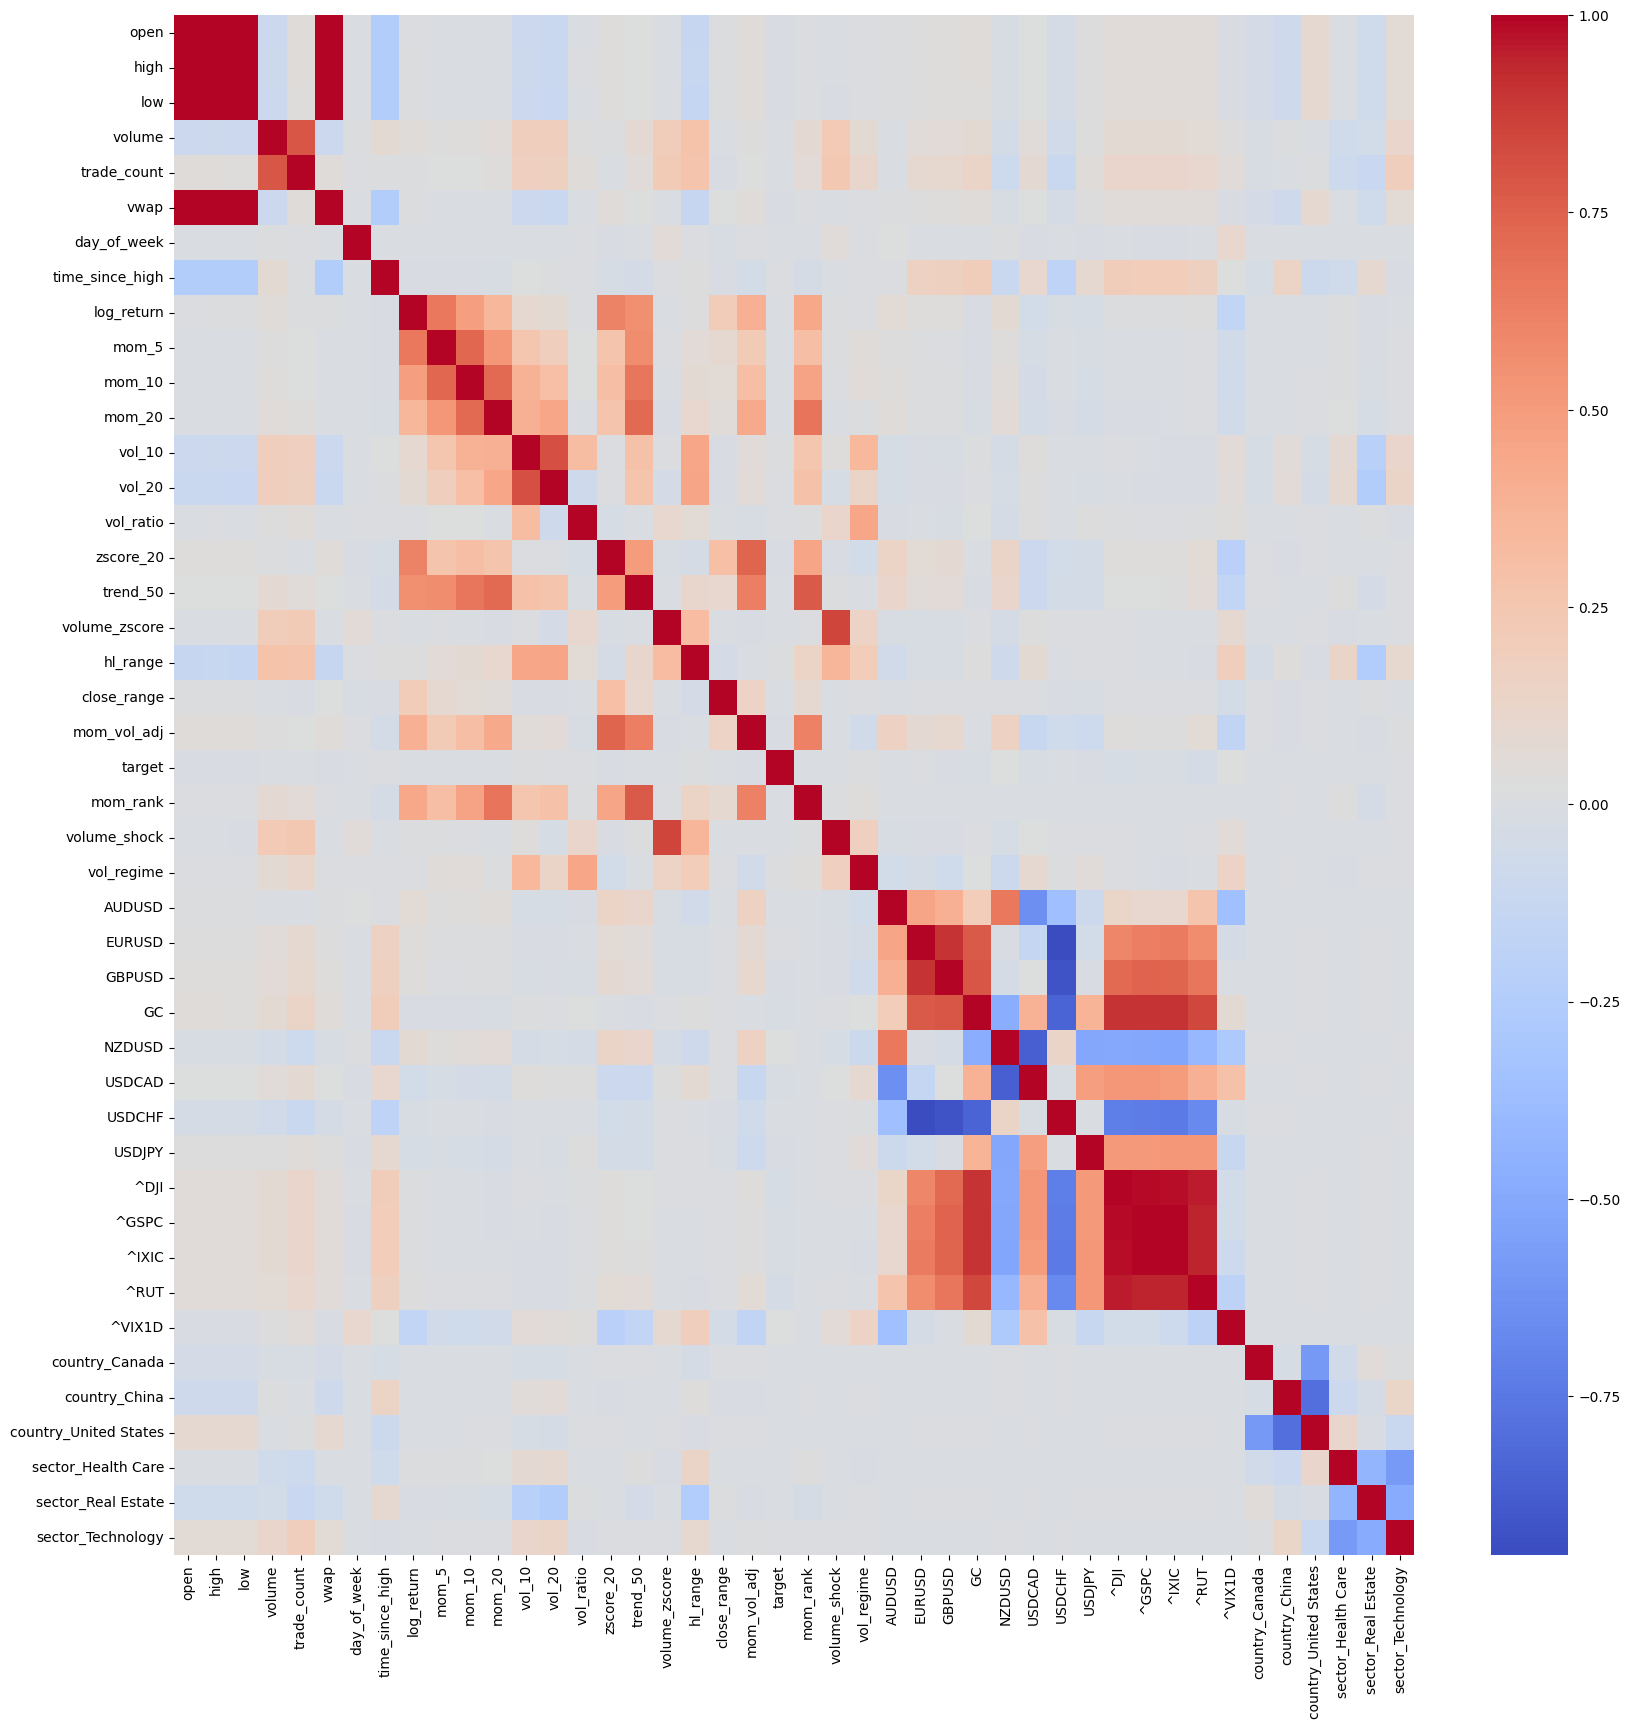

In [38]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [39]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins[label_column]
label_max = maxs[label_column]
hayai_util.save_normalization_params(label_min, label_max)

True

## Model building

In [40]:
labels = df[label_column].values
df = df.drop(columns=[label_column])
data = df.values


In [41]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (374475,)
Data Shape: (374475, 43)
Train Data Shape: (299580, 43)
Train Labels Shape: (299580,)
Test Data Shape: (74895, 43)
Test Labels Shape: (74895,)


In [42]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(64, activation='relu',name='layerDense1'))
model.add(Dense(32, activation='relu',name='layerDense2'))
model.add(Dense(16, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
3745/3745 - 5s - 1ms/step - loss: 1.9414e-04 - val_loss: 6.9394e-06
Epoch 2/20
3745/3745 - 5s - 1ms/step - loss: 1.8846e-05 - val_loss: 5.1696e-06
Epoch 3/20
3745/3745 - 5s - 1ms/step - loss: 1.8228e-05 - val_loss: 4.3194e-06
Epoch 4/20
3745/3745 - 4s - 1ms/step - loss: 1.7832e-05 - val_loss: 4.1046e-06
Epoch 5/20
3745/3745 - 3s - 911us/step - loss: 1.7621e-05 - val_loss: 4.8879e-06
Epoch 6/20
3745/3745 - 4s - 951us/step - loss: 1.7155e-05 - val_loss: 4.0140e-06
Epoch 7/20
3745/3745 - 4s - 1ms/step - loss: 1.7308e-05 - val_loss: 4.3097e-06
Epoch 8/20
3745/3745 - 4s - 1ms/step - loss: 1.6962e-05 - val_loss: 3.8525e-06
Epoch 9/20
3745/3745 - 4s - 1ms/step - loss: 1.6905e-05 - val_loss: 3.9150e-06
Epoch 10/20
3745/3745 - 5s - 1ms/step - loss: 1.6783e-05 - val_loss: 4.1092e-06
Epoch 11/20
3745/3745 - 4s - 1ms/step - loss: 1.6573e-05 - val_loss: 3.9897e-06
Epoch 12/20
3745/3745 - 4s - 1ms/step - loss: 1.6764e-05 - val_loss: 3.8081e-06
Epoch 13/20
3745/3745 - 4s - 1ms/step - loss:

Model saved to: data\mix_train\model.keras


In [44]:
tp = 0
tn = 0
fp = 0
fn = 0
print(label_min, label_max, label_max - label_min)
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

-761.1142909020324 100.25570804999687 861.3699989520293
Label: 0.8188, Prediction: 0.5750
Label: -2.0144, Prediction: 0.4258
Label: 0.4676, Prediction: -0.4299
Label: 2.9591, Prediction: 0.0472
Label: -0.0923, Prediction: 0.5587
Label: 0.1838, Prediction: 0.2888
Label: 0.8215, Prediction: 0.0178
Label: -0.8066, Prediction: 0.1926
Label: -0.2638, Prediction: 0.0644
Label: 0.4430, Prediction: 0.0617
Label: 2.0821, Prediction: -0.0472
Label: -1.5423, Prediction: -0.3945
Label: 0.0577, Prediction: -0.4765
Label: 0.0985, Prediction: 0.1007
Label: -0.6355, Prediction: -0.5562
Label: 3.0188, Prediction: 0.2246
Label: 0.7425, Prediction: 0.2134
Label: 0.7832, Prediction: 0.2065
Label: -3.5418, Prediction: 0.1538
Label: 1.2450, Prediction: -0.0230
Label: -1.2196, Prediction: 0.2831
Label: -0.6060, Prediction: -0.1995
Label: 0.0580, Prediction: 0.0325
Label: -0.1967, Prediction: 0.3774
Label: -1.0120, Prediction: -0.4255
Label: -0.2339, Prediction: 0.8974
Label: 1.1851, Prediction: 0.1085
Label: